# Executive summary
- Novel method for combining four sets of disjoint tiles with better calibration than each set alone.
- Illustrate with simple example showcasing good performance and solving problems of original tiles (without retraining BLISS encoder).

# Example catalog
Consider original tiles + one overlapping layer where both height and width are shifted by 2 pixels.

In [1]:
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf
from einops import rearrange, repeat, reduce
import torch
import numpy as np

from case_studies.sdss_galaxies_vae.reconstruction import load_models, reconstruct_scene_at_coordinates

In [2]:
import os
os.environ["BLISS_HOME"] = "/home/dereklh/projects/bliss/"

In [3]:
with initialize(config_path="../sdss_galaxies_vae/config", job_name="overlap"):
    cfg = compose(config_name="config", overrides = ["+reconstruct=sdss_figures"])   

In [4]:
import matplotlib.pyplot as plt

In [5]:
# load bliss
device = torch.device(cfg.reconstruct.device)
decoder, encoder, _ = load_models(cfg, device)
bp = encoder.border_padding

In [6]:
frame = instantiate(cfg.reconstruct.frame)

In [7]:
h_topleft = bp
w_topleft = bp
h_end = ((frame.image.shape[2] - 2 * bp) // 4) * 4 + bp
w_end = ((frame.image.shape[3] - 2 * bp) // 4) * 4 + bp
hlims = (h_topleft, h_end)
wlims = (w_topleft, w_end)
_, tile_map_recon = reconstruct_scene_at_coordinates(
    encoder, decoder, frame.image, frame.background, hlims, wlims
)

Encoding ptiles: 24it [00:10,  2.33it/s]


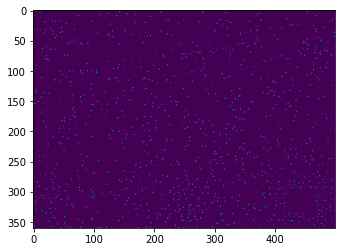

In [8]:
%matplotlib inline
plt.imshow(tile_map_recon["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

In [9]:
def plot_annotated_img(img, every_other_tile = False, plt=plt): 
    plt.imshow(img, vmin=0.0, vmax=1.0)
    for (j,i),label in np.ndenumerate(img):
        if ((i % 2 == 0) and (j % 2 == 0)) or (not every_other_tile):
            #l = f"{label:.2f}"
            l = int(label * 100)
            if l > 70:
                color = "b"
            else:
                color = "w"
#             print(l, label)
            plt.text(i,j,l,ha='center',va='center', color=color)

In [10]:
cfg.reconstruct.scenes.sdss_recon2


{'h': 460, 'w': 742, 'size': 300}

In [11]:
def plot_img_with_tiles(img, color="cyan", plt=plt):
    plt.imshow(img)
    for grid in range(3, img.shape[-1], 4):
        plt.axvline(grid + 0.5, color=color)
    for grid in range(3, img.shape[-2], 4):
        plt.axhline(grid + 0.5, color=color)
        

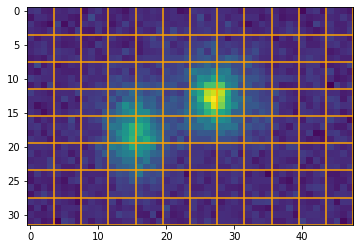

In [12]:
plot_img_with_tiles(frame.image[0, 0, 460:492, 740:788], color = "orange")

In [13]:
h_start = ((460 - bp) // 4)
w_start = ((740 - bp) // 4)

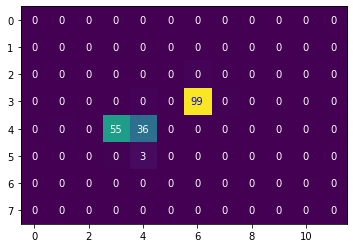

In [14]:
plot_annotated_img(tile_map_recon["n_source_log_probs"][0, h_start:(h_start + 8), w_start:(w_start + 12), 0, 0].exp().cpu())

In [15]:
# Shift inference to the left by two pixels

In [16]:
h_topleft2 = bp + 2
w_topleft2 = bp + 2
h_end2 = ((frame.image.shape[2] - 2 * bp - 2) // 4) * 4 + bp + 2
w_end2 = ((frame.image.shape[3] - 2 * bp - 2) // 4) * 4 + bp + 2
hlims2 = (h_topleft2, h_end2)
wlims2 = (w_topleft2, w_end2)
_, tile_map_recon2 = reconstruct_scene_at_coordinates(
    encoder, decoder, frame.image, frame.background, hlims2, wlims2
)

Encoding ptiles: 24it [00:10,  2.34it/s]


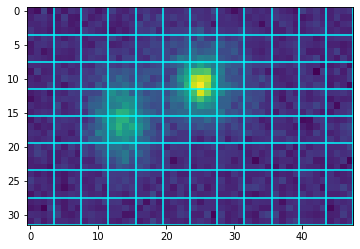

In [17]:
plot_img_with_tiles(frame.image[0, 0, 462:494, 742:790])

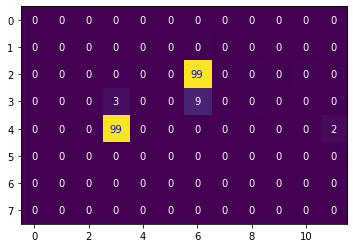

In [18]:
plot_annotated_img(tile_map_recon2["n_source_log_probs"][0, h_start:(h_start + 8), w_start:(w_start + 12), 0, 0].exp().cpu())

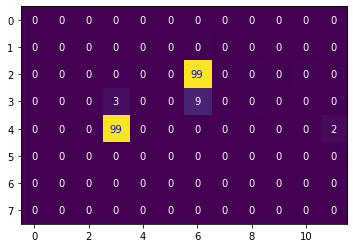

In [19]:
tile_cat_cropped = tile_map_recon2.crop((h_start, h_start + 8), (w_start, w_start + 12))
plot_annotated_img(tile_cat_cropped["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

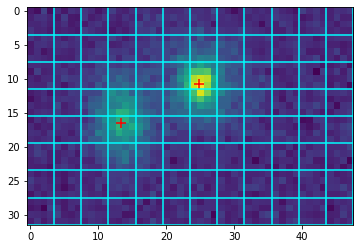

In [20]:
full_cat_cropped = tile_cat_cropped.to("cpu").to_full_params()
plot_img_with_tiles(frame.image[0, 0, 462:494, 742:790])
plt.scatter(full_cat_cropped.plocs[0, :, 1] - 0.5, full_cat_cropped.plocs[0, :, 0] - 0.5, marker = "+", s=100, c="r")

In [21]:
full_cat_cropped.plocs.shape

torch.Size([1, 2, 2])

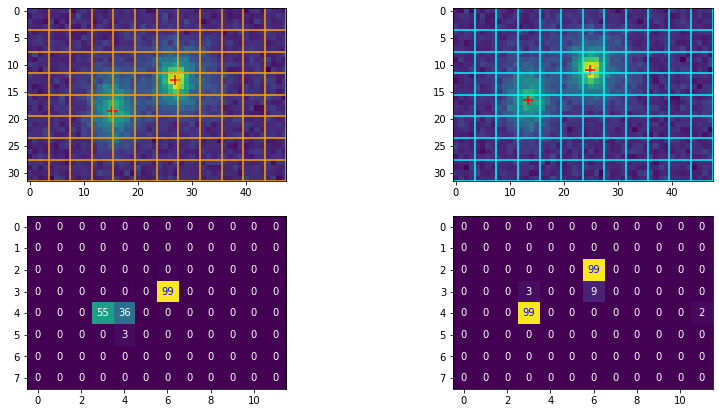

In [277]:
plt.rcParams['figure.figsize'] = [14, 7]
fig, axes = plt.subplots(2, 2)
plot_img_with_tiles(frame.image[0, 0, 460:492, 740:788], color = "orange", plt=axes[0,0])
plot_annotated_img(tile_map_recon["n_source_log_probs"][0, h_start:(h_start + 8), w_start:(w_start + 12), 0, 0].exp().cpu(), plt=axes[1, 0])
axes[0, 0].scatter(full_cat_cropped.plocs[0, :, 1] - 0.5 + 2, full_cat_cropped.plocs[0, :, 0] - 0.5 + 2, marker = "+", s=100, c="r")
plot_img_with_tiles(frame.image[0, 0, 462:494, 742:790], plt=axes[0, 1])
plot_annotated_img(tile_map_recon2["n_source_log_probs"][0, h_start:(h_start + 8), w_start:(w_start + 12), 0, 0].exp().cpu(), plt=axes[1,1])
axes[0, 1].scatter(full_cat_cropped.plocs[0, :, 1] - 0.5, full_cat_cropped.plocs[0, :, 0] - 0.5, marker = "+", s=100, c="r")



# Overlapping procedure
First, we shift the input image by two pixels in each direction and feed each to the encoder to get four different estimates.

The original BLISS encoder was trained on a rate of 0.04. Since we have four overlapping tiles, we need to adjust this rate down to 0.01.

In [121]:
def adj_prob(p, r):
    a = p * r
    b = (1 - p) / r
    return a / (a + b)

In [122]:
adj_prob(0.999, 0.25)

0.9842364532019703

In [123]:
def make_imgs_and_bgs(img2, bg2):
    imgs = []
    bgs = []
    for w in (0, 2):
        for h in (0, 2):
            img_shifted = torch.zeros_like(img2)
            img_shifted[:, :, :(-h if h != 0 else None), :(-w if w != 0 else None)] = img2[:, :, h:, w:]
            bg_shifted = torch.zeros_like(bg2)
            bg_shifted[:, :, :(-h if h != 0 else None), :(-w if w != 0 else None)]  = bg2[:, :, h:, w:]
            if h > 0:
                img_shifted[:, :, -h:, :] = bg2[:, :, -h:, :]
                bg_shifted[:, :, -h:, :] = bg2[:, :, -h:, :]
            if w > 0:
                img_shifted[:, :, :, -w:] = bg2[:, :, :, -w:]
                bg_shifted[:, :, :, -w:] = bg2[:, :, :, -w:]
            if (h > 0) and (w > 0):
                img_shifted[:, :, -h:, -w:] = bg2[:, :, -h:, -w:]
                bg_shifted[:, :, -h:, -w:] = bg2[:, :, -h:, -w:]
            imgs.append(img_shifted)
            bgs.append(bg_shifted)
    return imgs, bgs
imgs, bgs = make_imgs_and_bgs(
    img2 = frame.image[:, :, (460-bp):(492+bp), (740-bp):(788+bp)],
    bg2 = frame.background[:, :, (460-bp):(492+bp), (740-bp):(788+bp)]
)

In [28]:
tile_maps = []
for img, bg in zip(imgs, bgs):
    _, _, h, w = img.shape
    _, tile_map_shifted = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h - bp), (bp, w - bp))
    tile_maps.append(tile_map_shifted)

Encoding ptiles: 1it [00:00, 29.87it/s]
Encoding ptiles: 1it [00:00, 91.77it/s]
Encoding ptiles: 1it [00:00, 92.25it/s]
Encoding ptiles: 1it [00:00, 93.23it/s]


In [29]:
log_probs_all = torch.stack([t["n_source_log_probs"][0, :, :, 0, 0] for t in tile_maps], dim = -1)

In [ ]:
prob_dbl = repeat(log_probs_all.exp(), "h w d -> (h h2) (w w2) d",h2=2, w2=2).cpu()
prob_super = torch.zeros(prob_dbl.shape[0] + 1, prob_dbl.shape[1] + 1, 4)

prob_super[:-1, :-1, 0] = prob_dbl[:, :, 0]
prob_super[1:, :-1, 1] = prob_dbl[:, :, 1]
prob_super[:-1, 1:, 2] = prob_dbl[:, :, 2]
prob_super[1:, 1:, 3] = prob_dbl[:, :, 3]

In [124]:
prob_super = adj_prob(prob_super, 0.25)

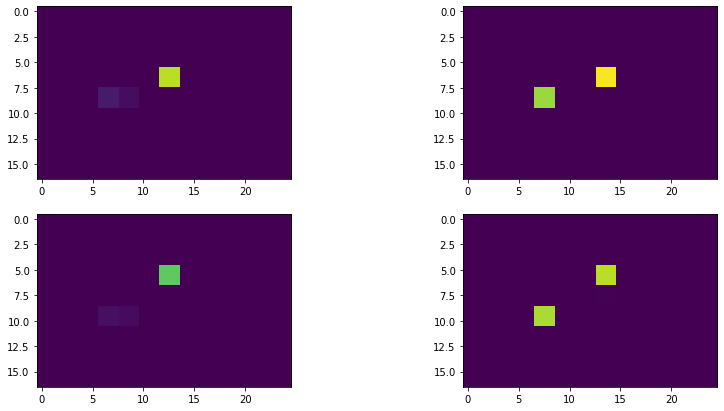

In [125]:
fig, axs = plt.subplots(2, 2)
for i in (0, 1):
    for j in (0, 1):
        axs[j, i].imshow(prob_super[:, :, 2*i + j], vmin=0, vmax=1)

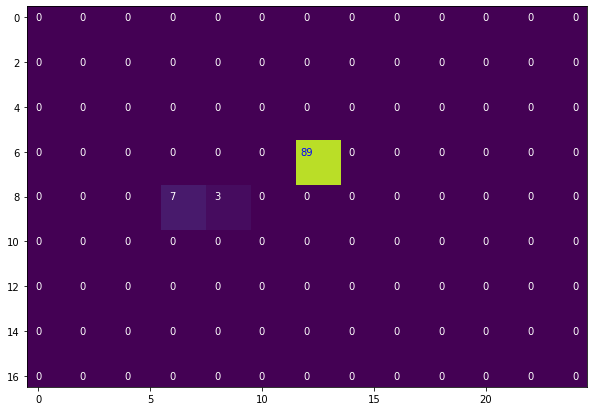

In [126]:
plot_annotated_img(prob_super[:, :, 0], every_other_tile=True)

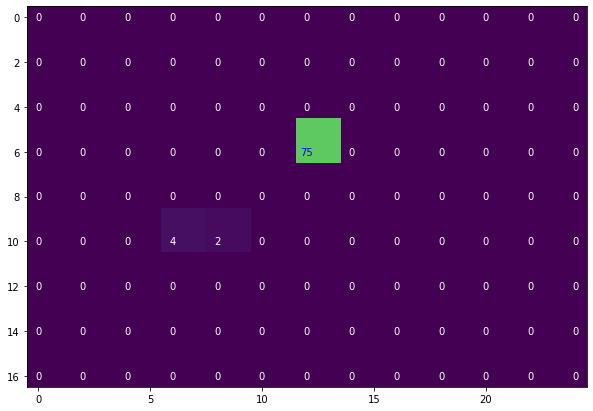

In [127]:
plot_annotated_img(prob_super[:, :, 1], every_other_tile=True)

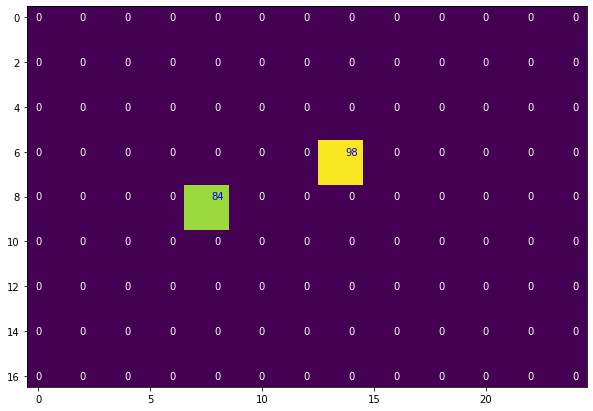

In [128]:
plot_annotated_img(prob_super[:, :, 2], every_other_tile=True)

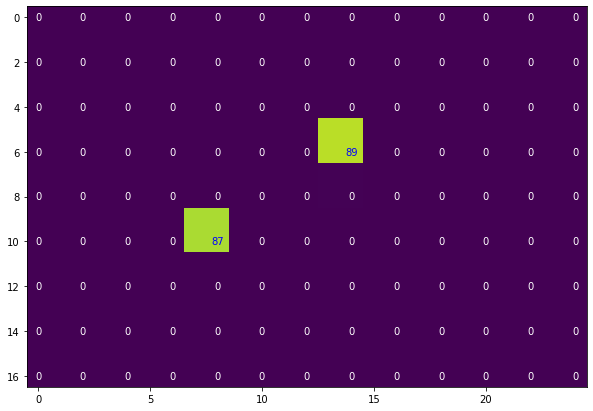

In [129]:
plot_annotated_img(prob_super[:, :, 3], every_other_tile=True)

# Overlapping tiles variational distribution

In [130]:
def get_comparison_indices(offset):
    if offset == 1:
        return 1, None, 0, -1
    elif offset == -1:
        return 0, -1, 1, None
    raise ValueError()

In [131]:
def has_no_neighbor(offset_h, offset_w, tiles_other):
    no_neighbors = (~tiles_other[:, :])
    if offset_h != 0:
        ah,bh,ch,dh = get_comparison_indices(offset_h)
        no_neighbors[ah:bh, :] &= (~tiles_other[ch:dh, :])
    if offset_w != 0:
        aw,bw,cw,dw = get_comparison_indices(offset_w)
        no_neighbors[:, aw:bw] &= (~tiles_other[:, cw:dw])
    if ((offset_h != 0) and (offset_w != 0)):
        no_neighbors[ah:bh, aw:bw] &= (~tiles_other[ch:dh, cw:dw])
    return no_neighbors

In [132]:
def has_no_neighbor_all_four(idx, tiles, offsets):
    no_neighbors = torch.ones_like(tiles[:, :, idx])
    own_offset = offsets[idx]
    for other, (offset_h, offset_w) in enumerate(offsets):
        if other != idx:
            offset_h = offset_h - own_offset[0]
            offset_w = offset_w - own_offset[1]
            n = has_no_neighbor(offset_h, offset_w, tiles[:, :, other])
            no_neighbors *= n
    return no_neighbors

In [233]:
def sample_tile_marginals_from_cats(tile_maps, offsets, n_iter=1_000, adj=None):
    log_probs = torch.stack([t["n_source_log_probs"][0, :, :, 0, 0] for t in tile_maps], dim = -1)
    if adj is not None:
        log_probs = adj_prob(log_probs.exp(), adj).log()
    tiles = torch.zeros(n_iter, *log_probs.shape, dtype=bool, device=log_probs.device)
    for i in range(n_iter):
        for idx, offset in enumerate(offsets):
            if idx == 0:
                i_prev = 0 if i==0 else i-1
                tiles[i] = tiles[i_prev]
            no_neighbors = has_no_neighbor_all_four(idx, tiles[i], offsets)
            log_unif = torch.rand_like(tiles[i, :, :, idx], dtype=float).log()
            log_prob = log_probs[:, :, idx] + no_neighbors.log()
            tiles[i, :, :, idx] = log_unif < log_prob
            assert torch.allclose(tiles[i, :, :, idx] & no_neighbors, tiles[i, :, :, idx])
    return tiles.float().mean(0), tiles

In [267]:
xx_offsets = [
    (0,0),
#     (1,0),
#     (0,1),
    (1,1),
]
xx, tile_samples = sample_tile_marginals_from_cats([tile_maps[0], tile_maps[3]], xx_offsets, n_iter=10_000, adj=0.5)

In [269]:
xx_dbl = repeat(xx, "h w d -> (h h2) (w w2) d",h2=2, w2=2).cpu()
xx_super = torch.zeros(xx_dbl.shape[0] + 1, xx_dbl.shape[1] + 1, 2)

xx_super[:-1, :-1, 0] = xx_dbl[:, :, 0]
# xx_super[1:, :-1, 1] = xx_dbl[:, :, 1]
# xx_super[:-1, 1:, 2] = xx_dbl[:, :, 2]
xx_super[1:, 1:, 1] = xx_dbl[:, :, 1]

These are the marginal probabilities of each tile

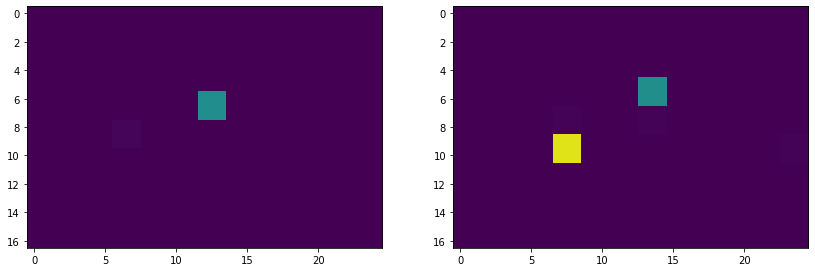

In [273]:
fig, axs = plt.subplots(1, 2)
for i in (0, 1):
        axs[i].imshow(xx_super[:, :, i].cpu(), vmin=0, vmax=1)

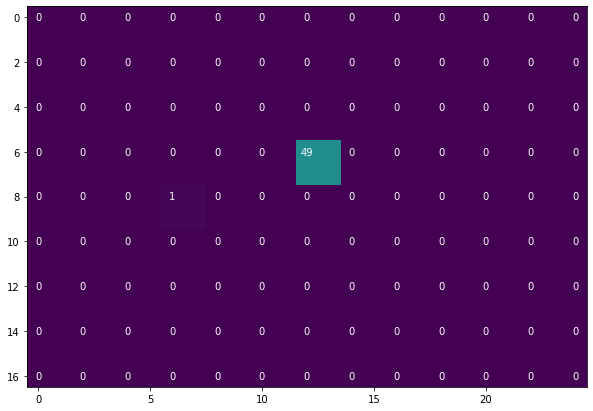

In [274]:
plot_annotated_img(xx_super[:,:, 0], every_other_tile=True)

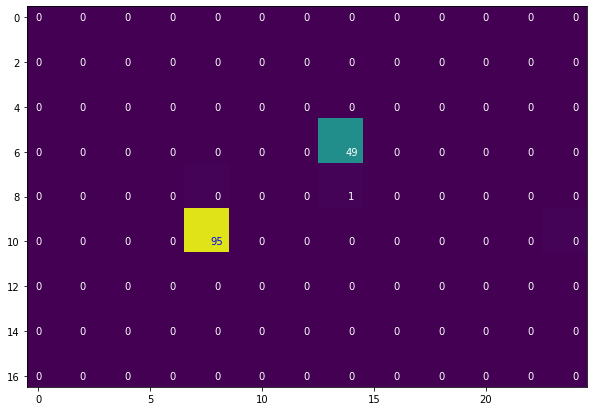

In [275]:
plot_annotated_img(xx_super[:,:, 1],  every_other_tile=True)

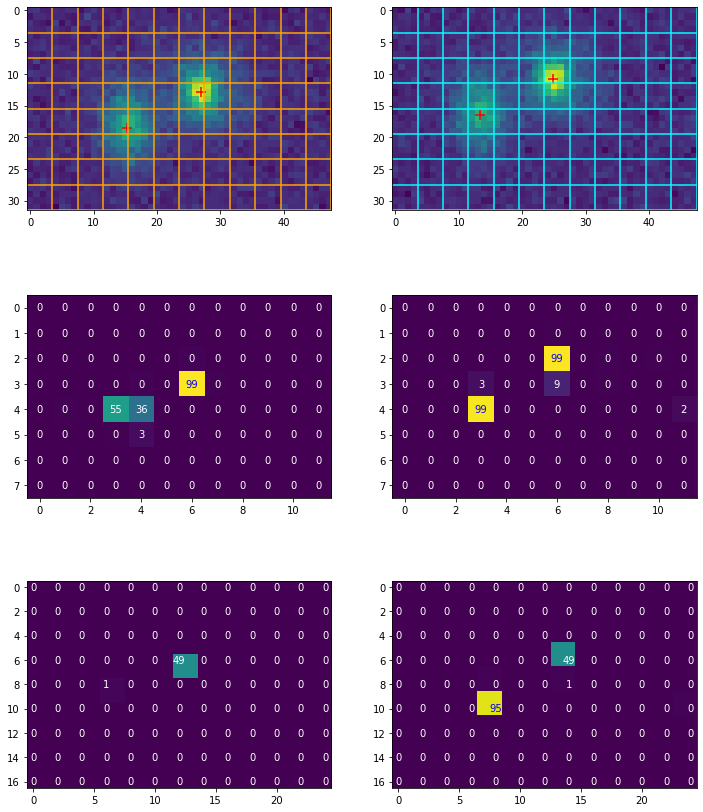

In [287]:
plt.rcParams['figure.figsize'] = [12, 15]
fig, axes = plt.subplots(3, 2)
plot_img_with_tiles(frame.image[0, 0, 460:492, 740:788], color = "orange", plt=axes[0,0])
plot_annotated_img(tile_map_recon["n_source_log_probs"][0, h_start:(h_start + 8), w_start:(w_start + 12), 0, 0].exp().cpu(), plt=axes[1, 0])
axes[0, 0].scatter(full_cat_cropped.plocs[0, :, 1] - 0.5 + 2, full_cat_cropped.plocs[0, :, 0] - 0.5 + 2, marker = "+", s=100, c="r")
plot_img_with_tiles(frame.image[0, 0, 462:494, 742:790], plt=axes[0, 1])
plot_annotated_img(tile_map_recon2["n_source_log_probs"][0, h_start:(h_start + 8), w_start:(w_start + 12), 0, 0].exp().cpu(), plt=axes[1,1])
axes[0, 1].scatter(full_cat_cropped.plocs[0, :, 1] - 0.5, full_cat_cropped.plocs[0, :, 0] - 0.5, marker = "+", s=100, c="r")
plot_annotated_img(xx_super[:,:, 0], every_other_tile=True, plt=axes[2, 0])
plot_annotated_img(xx_super[:,:, 1], every_other_tile=True, plt=axes[2, 1])

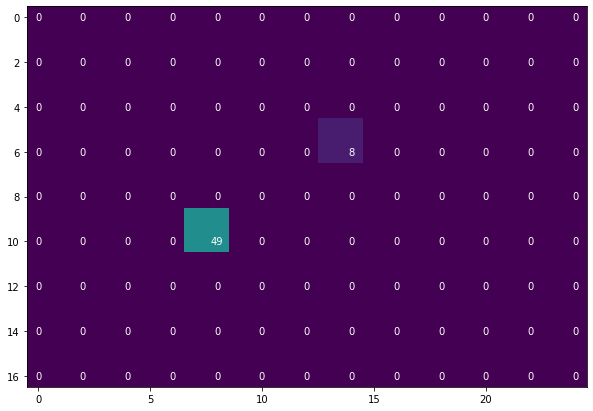

In [264]:
plot_annotated_img(xx_super[:,:, 3], every_other_tile=True)

New estimate of number of objects in area

In [265]:
xx.sum()

tensor(1.9512, device='cuda:0')

This estimate makes sense, as there could be more than two objects that aren't easily detected.

In [246]:
2 + 0.04 * 25 * 0.2

2.2

Each individual tiling estimate underestimates the number of objects (though some of that is a boundary issue since the top-right object goes out of range).

In [247]:
reduce(log_probs_all.exp(), "nth ntw d -> d", "sum")

tensor([2.0455, 1.8857, 2.1296, 2.2364], device='cuda:0')

The third set of disjoint tiles only happens to be close to the true because it under-estimates the object to the upper-right and over-estimates the object to the bottom-left.

In [248]:
log_probs_all.exp().sum() / 4

tensor(2.0743, device='cuda:0')

# Inference of non-overlapping subtiles

We can recover a non-overlapping marginal over subtiles by utilizing the estimated mean and covariance associated with each tile. Given that a tile generated an object, we can calculate which subtile it fell in using a normal CDF.

In [249]:
loc_means = torch.stack([t["loc_mean"][0, :, :, 0, :] for t in tile_maps], dim = -1)
loc_sds = torch.stack([t["loc_sd"][0, :, :, 0, :] for t in tile_maps], dim = -1)

In [150]:
loc_means.shape

torch.Size([8, 12, 2, 4])

In [151]:
loc_sds.shape

torch.Size([8, 12, 2, 4])

In [152]:
loc_means_h = loc_means[:, :, 0]
loc_means_w = loc_means[:, :, 1]
loc_sds_h = loc_sds[:, :, 0]
loc_sds_w = loc_sds[:, :, 1]
dist_h = torch.distributions.Normal(loc_means_h, loc_sds_h)
dist_w = torch.distributions.Normal(loc_means_w, loc_sds_w)

device = loc_means_h.device
start = torch.tensor(0.0, device = device)
mid = torch.tensor(0.5, device = device)
end = torch.tensor(1.0, device = device)

prob_h_top = (dist_h.cdf(mid) - dist_h.cdf(start)) / (dist_h.cdf(end) - dist_h.cdf(start))
prob_h_bot = 1 - prob_h_top
prob_h = torch.stack((prob_h_top, prob_h_bot), dim=-1)
prob_h = rearrange(prob_h, "nl nth ntw sh -> nl nth ntw sh 1", sh=2)

prob_w_left = (dist_w.cdf(mid) - dist_w.cdf(start)) / (dist_w.cdf(end) - dist_w.cdf(start)) 
prob_w_right = 1 - prob_w_left
prob_w = torch.stack((prob_w_left, prob_w_right), dim=-1)
prob_w = rearrange(prob_w, "nl nth ntw sw -> nl nth ntw 1 sw", sw=2)

probs_in_tile = prob_h * prob_w

In [153]:
probs_in_tile.shape

torch.Size([8, 12, 4, 2, 2])

In [154]:
tile_samples

tensor([[[[False, False, False, False],
          [False, False, False, False],
          [False, False, False, False],
          ...,
          [False, False, False, False],
          [False, False, False, False],
          [False, False, False, False]],

         [[False, False, False, False],
          [False, False, False, False],
          [False, False, False, False],
          ...,
          [False, False, False, False],
          [False, False, False, False],
          [False, False, False, False]],

         [[False, False, False, False],
          [False, False, False, False],
          [False, False, False, False],
          ...,
          [False, False, False, False],
          [False, False, False, False],
          [False, False, False, False]],

         ...,

         [[False, False, False, False],
          [False, False, False, False],
          [False, False, False, False],
          ...,
          [False, False, False, False],
          [False, False, False, False],

In [155]:
tiles_dbl = repeat(tile_samples, "ns h w d -> ns h w d h2 w2",h2=2, w2=2)

In [156]:
tiles_dbl.shape

torch.Size([10000, 8, 12, 4, 2, 2])

In [157]:
probs_in_subtiles = tiles_dbl * probs_in_tile.unsqueeze(0)

In [158]:
probs_in_subtiles.shape

torch.Size([10000, 8, 12, 4, 2, 2])

In [159]:
probs_subtiles = torch.zeros(xx_dbl.shape[0] + 1, xx_dbl.shape[1] + 1, device=probs_in_subtiles.device)

p2 = reduce(probs_in_subtiles, "ns nth ntw nl h2 w2 -> (nth h2) (ntw w2) nl", "mean")

probs_subtiles[:-1, :-1] += p2[:, :, 0]
probs_subtiles[1:, :-1] += p2[:, :, 1]
probs_subtiles[:-1, 1:] += p2[:, :, 2]
probs_subtiles[1:, 1:] += p2[:, :, 3]

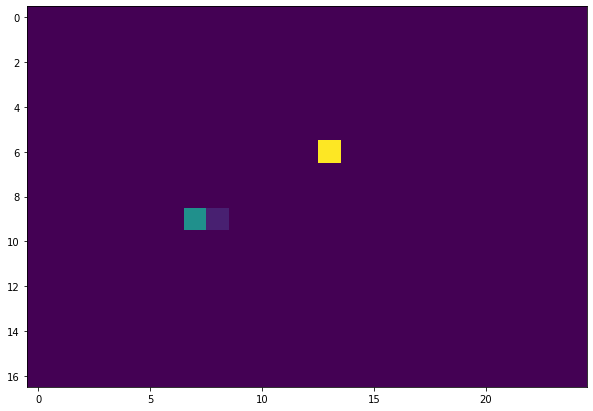

In [160]:
plt.imshow(probs_subtiles.cpu())

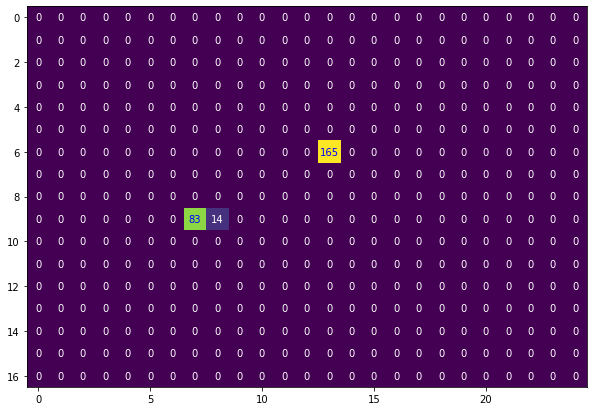

In [161]:
plot_annotated_img(probs_subtiles.cpu(), every_other_tile=False)

In [ ]:
probs_subtiles[7:9, 3:5]

In [ ]:
probs_subtiles[7:9, 3:5].sum()

In [ ]:
probs_subtiles.sum()

In [ ]:
probs_subtiles[:2, -3:]

In [ ]:
def simple_gibbs(n=10_000):
    x1 = 0
    x2 = 0
    s1 = 0
    s2 = 0
    for _ in range(n):
        x1 = ((torch.rand(1) * (1 - x1)) > 0.5).float()
        x2 = ((torch.rand(1) * (1 - x2)) > 0.5).float()
        s1 += x1
        s2 += x2
    return s1 / n, s2 / n

In [ ]:
simple_gibbs()

## New sleep phase training